## Using the QM9 Dataset

### About the dataset: 
 - Molecules consist of H,C,O,N and F atoms, and contain up to 9 heavy atoms. 
 - More information is available here: https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.datasets.QM9.html#torch_geometric.datasets.QM9

In [7]:
import torch
from torch_geometric.transforms import BaseTransform, Compose

from torch_geometric.datasets import QM9
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GATConv
import torch.nn.functional as f
from torch.nn import Linear, ReLU

from torch_geometric.nn import global_mean_pool
from matplotlib import pyplot as plt

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('using', device)
torch.set_default_device(device)

using cuda


## Some tools to help with the data

In [3]:

class SetTarget(BaseTransform):
    '''
    Transform to modify target vector so there is a single value.
    
    Choose from 0-18 for target values described here: 
    https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.datasets.QM9.html#torch_geometric.datasets.QM9
    '''
    def __init__(self,target):
        self.target = target
        
    def __call__(self,data):
        data.y = data.y[:,self.target]
        return data

class NormalizeTarget(BaseTransform):
    '''
    Transform to normalize target vector.

    Parameters:
    ----------
    mean : mean of the training data target values 
    std : standard deviation of the training data target values
    
    '''
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def __call__(self, data):
        data.y = (data.y - self.mean) / self.std
        return data

## Plotting methods

In [4]:
# Some functions to plot stuff 

def plot_pred_v_actual(preds, actual, title=''):
    '''
    Plot predicted vs actual/expected values as a scatter plot
    
    Parameters: 
    ----------
    preds : numpy array 
            predicted values 
    actual : numpy array
            expected values
    title : string
            Title for plot (optional)
    '''
    fig, ax = plt.subplots(figsize=(10,7.5))

    # Set the default text font size
    plt.rc('figure', titlesize=16)
    plt.rc('font', size=12)

    min_val = min(min(preds), min(actual))
    max_val = max(max(preds), max(actual))
    lims = [min_val, max_val]

    # now plot both limits against eachother
    ax.plot(lims, lims, 'k--', alpha=0.75)

    ax.set_aspect('equal')
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    ax.scatter(actual, preds, s=20)
    
    if title == '':
        ax.set_title("Predicted vs Actuals")
    else:
        ax.set_title(title)

    plt.xlabel("prediction")
    plt.ylabel("actual")

    plt.show()


def plot_losses(tlosses, vlosses):
    '''
    Plot training and validation losses per epoch
    Expectation is that losses are ordered starting with same epoch (0) 
    
    Parameters: 
    ----------
    tlosses : list of floats 
                training loss values
    vlosses : list of floats
                validation loss values
    
    '''
    plt.figure(figsize=(10,5))
    plt.plot(tlosses, label = "Training", c='r')
    plt.plot(vlosses, label = "Validation", c='b')
    plt.legend()
    plt.ylabel("Loss")
    plt.xlabel("Epoch")
    plt.title("Training and Validation Loss")
    plt.show()


## Loading the dataset

In [5]:
# this will create a folder called data in the same directory as this notebook
qm9 = QM9(root='data')


## Creating train/val/test datasets

In [8]:

#shuffle first so we get a nice variety
qm9 = qm9.shuffle()
#qm9.data.to(device)

# let's use 20k, and split to train/val/test 70/10/20
sample_count = 20000
train_end = int(sample_count * 0.7)
val_end = train_end + int(sample_count* 0.1)
test_end = val_end + int(sample_count * 0.2)

# normalizing the target values can help when using neural networks, let's do that
# collect the target y values from the training to use for normalizing
train_y2 =torch.cat([qm9[i].y for i in range(train_end)], dim=0)

# compute mean and standard deviation
train_mean = train_y2.mean()
train_std = train_y2.std()

# We are going set our prediction target variable here and also normalize in the transform:
# 11 = Heat capacity at 298.15K
target_index = 11

# transform values
qm9.transform = Compose([SetTarget(target_index),NormalizeTarget(train_mean, train_std)])


# use the DataLoader
# set the batch size
batch = 50
gen = torch.Generator(device=device)
train_loader = DataLoader(qm9[:train_end], batch_size = batch, shuffle = True, generator=gen)
val_loader = DataLoader(qm9[train_end:val_end], batch_size = batch, shuffle = True, generator=gen)
test_loader = DataLoader(qm9[val_end:test_end], batch_size = batch, shuffle = False, generator=gen)



## Some Models

### Simple GCN

In [9]:
# Starting with a simple GCN

class GCN(torch.nn.Module):
    '''
    Graph Convolutional Network 

    '''
    def __init__(self,num_features, h):
        '''
        Init for GCN class

        Parameters:
        num_features : integer
                     number of features from the data
        h : integer
            number of hidden layers

        '''
        super().__init__()
        self.conv1 = GCNConv(num_features, h)
        self.conv2 = GCNConv(h, h)
        self.linear = Linear(h, 1)
    
    def forward(self, data):
        e = data.edge_index
        x = data.x

        x = self.conv1(x, e)
        x = x.relu()
        x = self.conv2(x, e)
        x = global_mean_pool(x, data.batch)

        x = f.dropout(x, p=0.25, training=self.training)
        x = self.linear(x)

        return x


### Graph Attention Network Model

In [10]:

class GATConvModel(torch.nn.Module):
    '''
    Graph Attention Network - our basic starting model

    '''
    def __init__(self,num_features, h):
        '''
        Init for GATConv class

        Parameters:
        ----------
        num_features : integer
                     number of features from the data
        h : integer
            number of hidden layers

        Returns: 
        -------
        x : updated graph nodes
        '''
        super().__init__()
        self.conv1 = GATConv(num_features, h)
        self.conv2 = GATConv(h, h)
        self.linear = Linear(h, 1)
    
    def forward(self, data):
        e = data.edge_index
        x = data.x

        x = self.conv1(x, e)
        x = x.relu()
        x = self.conv2(x, e)
        x = global_mean_pool(x, data.batch)

        x = f.dropout(x, p=0.25, training=self.training)
        x = self.linear(x)

        return x


### Methods for Training and Evaluating the Models

In [11]:
# This is our training method, notice it's not model specific, so we will use it with any model we want to try

# Here we are printing the loss values for train and validation every 50 epochs, but we could modify this to 
# print more or less often

def train_model(model, epochs, loss_function, optimizer, train_loader, val_loader):
    '''
    Train the model

    Parameters: 
    ----------
    model : nn model to train

    epochs : integer
            number of epochs to train the model

    loss_function : function to evaluate model performance

    optimizer : optimizer to use during training

    train_loader : dataloader containing training data

    val_loader : dataloader containing validation data

    device : where to run

    Returns: 
    -------
    model : trained model
    
    tlosses: list containing floats 
            training losses from each epoch
            
    vlosses : list containing floats 
            validation losses from each epoch
    '''
    tlosses = []
    vlosses = []

    for epoch in range(epochs):
        # need model in training mode
        model.train()
        device = next(model.parameters()).device
        tloss = 0
        for data in train_loader: 
            #data.x = data.x.float()
            data = data.to(device)
            # forward step of model training
            out = model(data)
            loss = loss_function(out, torch.reshape(data.y, (len(data.y), 1)))
            tloss += loss/len(train_loader)
            # clear the gradients
            optimizer.zero_grad()
            # derive gradients
            loss.backward()
            # update parameters based on gradients
            optimizer.step()
        
        tlosses.append(tloss.item())

        # check the validation loss after this training epoch
        model.eval()
        with torch.no_grad():
            vloss = 0
            for data in val_loader:
                data = data.to(device)
                out = model(data)
                vloss += loss_function(out, torch.reshape(data.y, (len(data.y),1)))/len(val_loader)

            vlosses.append(vloss.item())

            if epoch%50 == 0:
                print(f"Epoch {epoch}: training loss:{tloss:.6e}, validation loss:{vloss:.6e}")
    print(f"Epoch {epoch}: training loss:{tloss:.6e}, validation loss:{vloss:.6e}")

    return model, tlosses, vlosses

In [12]:
# Here we are using @torch.no_grad() because we don't need to calculate gradients while doing evaluation in this function
# disabling this will improve performance (reduces memory usage) this is the same effect as using with torch.no_grad() as we did above
# also notice here we are returning only the predictions, since the model is not changing in the function, returning it is unnecessary

@torch.no_grad()
def evaluate_test(model, test_loader):
    '''
    Evaluate the test data

    Parameters: 
    ----------
    model : trained model

    test_loader : data to evaluate

    Returns:
    -------
    Predicted and expected values 
    '''
    model.eval()
    device = next(model.parameters()).device
    
    first = True

    for data in test_loader:
        data.to(device)
        test_out = model(data)
        test_out = torch.squeeze(test_out, 1)

        if first:
            ttest_out = test_out.detach()
            ttest_y = data.y.detach()
            first = False
        else:
            ttest_out = torch.concat((ttest_out, test_out.detach()))
            ttest_y = torch.concat((ttest_y, data.y.detach()))

    print(f"{loss_function(ttest_out, ttest_y).item():.6e}")

    return ttest_out, ttest_y

## Try our first model and plot the results

Epoch 0: training loss:4.575254e-03, validation loss:1.131594e-04
Epoch 50: training loss:3.733899e-07, validation loss:4.479680e-07
Epoch 100: training loss:3.180834e-07, validation loss:3.479628e-07
Epoch 150: training loss:3.156490e-07, validation loss:3.138678e-07
Epoch 199: training loss:2.841598e-07, validation loss:3.058166e-07
2.493751e-07
5.318075e+00


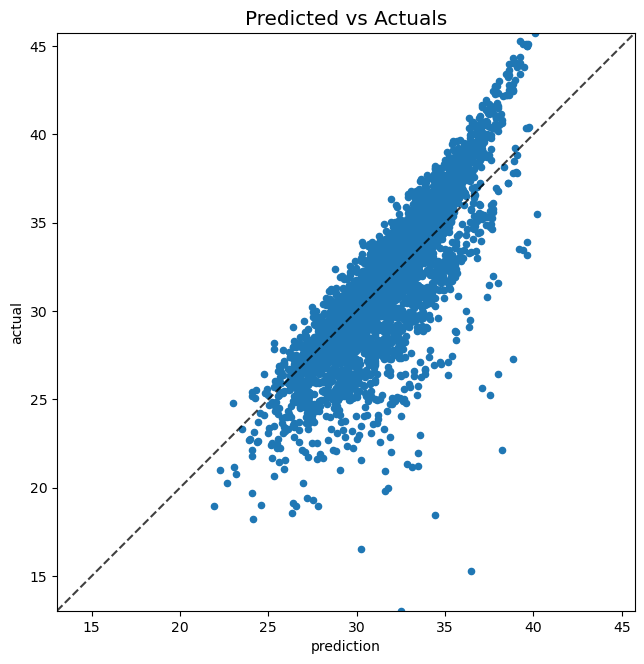

In [13]:
model = GCN(qm9.num_features, h = 64)
model.to(device)

epochs = 200
loss_function = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

model, tlosses, vlosses = train_model(model, epochs, loss_function, optimizer, train_loader, val_loader)

test_out, test_y = evaluate_test(model, test_loader)

# denormalize
denorm_out = (test_out * train_std) + train_mean
denorm_y = (test_y * train_std) + train_mean
print(f"Test loss:{loss_function(denorm_out, denorm_y).item():.6e}")

preds = denorm_out.cpu().detach().numpy()
actual = denorm_y.cpu().detach().numpy()

plot_pred_v_actual(preds, actual)

### Try a Graph Attention Network 

Notice that the only change is the model. The training and evaluation process is the same as we try different models.

Epoch 0: training loss:2.213931e-02, validation loss:1.531836e-04
Epoch 50: training loss:7.035811e-07, validation loss:4.516915e-07
Epoch 100: training loss:3.179021e-07, validation loss:4.985241e-07
Epoch 150: training loss:2.983855e-07, validation loss:3.130403e-07
Epoch 199: training loss:2.980706e-07, validation loss:3.045936e-07
2.519456e-07
Test loss:5.372879e+00


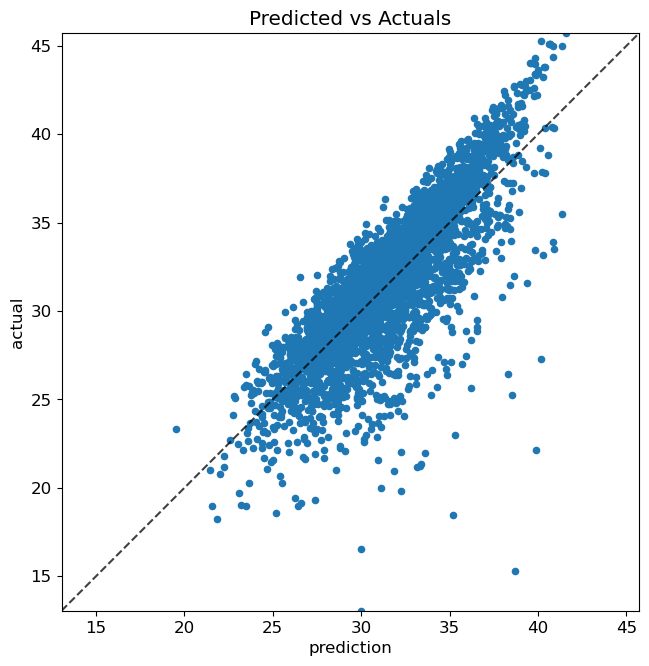

In [15]:
model2 = GATConvModel(qm9.num_features, h = 64)
model2.to(device)

epochs = 200
loss_function = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model2.parameters(), lr = 0.001)

model2, tlosses, vlosses = train_model(model2, epochs, loss_function, optimizer, train_loader, val_loader)

test_out, test_y = evaluate_test(model2, test_loader)

# denormalize
denorm_out = (test_out * train_std) + train_mean
denorm_y = (test_y * train_std) + train_mean
print(f"Test loss:{loss_function(denorm_out, denorm_y).item():.6e}")

preds = denorm_out.cpu().detach().numpy()
actual = denorm_y.cpu().detach().numpy()

plot_pred_v_actual(preds, actual)

### Try modifying the Attention Network model by adding another convolutional layer

Here we add a layer with half as many outputs, but we could have made other modifications. 
For example you could: 
 - Increase the number of outputs of an earlier layer and then reduce
 - Keep the number of outputs the same throughout
 - Reduce the number of outputs earlier
 - Anything else you want to try...

In [16]:
# let's modify our attention network model a little
    
class GATConvModel2(torch.nn.Module):
    '''
    Graph Attention Network model v2 - added a third GATConv layer

    '''
    def __init__(self, num_features, h):
        '''
        Init for GATConv class

        Parameters:
        num_features : integer
                     number of features from the data
        h : integer
            number of hidden layers

        '''
        super().__init__()
        self.conv1 = GATConv(num_features, h)
        self.conv2 = GATConv(h, h)
        # add another layer here, but with fewer outputs
        self.conv3 = GATConv(h, h//2)
        self.linear = Linear(h//2, 1)
    
    def forward(self, data):
        e = data.edge_index
        x = data.x

        x = self.conv1(x, e)
        x = x.relu()
        x = self.conv2(x, e)
        # add another relu and another conv
        x = x.relu()
        x = self.conv3(x, e)

        x = global_mean_pool(x, data.batch)

        x = f.dropout(x, p=0.25, training=self.training)
        x = self.linear(x)

        return x

Epoch 0: training loss:5.342287e-03, validation loss:1.581851e-04
Epoch 50: training loss:3.965606e-07, validation loss:3.144891e-07
Epoch 100: training loss:3.183343e-07, validation loss:3.290116e-07
Epoch 150: training loss:2.938068e-07, validation loss:3.084052e-07
Epoch 199: training loss:2.917723e-07, validation loss:3.689278e-07
2.830775e-07
6.036803e+00


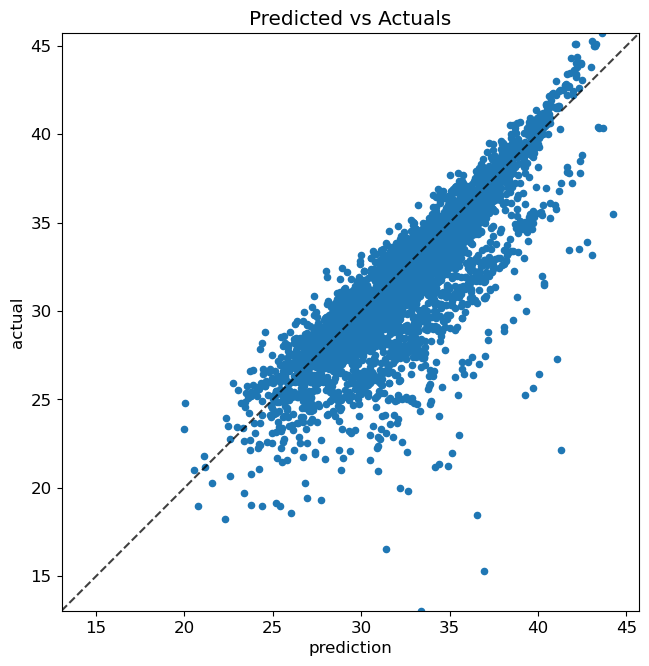

In [17]:
model3 = GATConvModel2(qm9.num_features, h = 64)

epochs = 200
loss_function = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model3.parameters(), lr = 0.001)

model3, tlosses, vlosses = train_model(model3, epochs, loss_function, optimizer, train_loader, val_loader)

test_out, test_y = evaluate_test(model3, test_loader)

# denormalize
denorm_out = (test_out * train_std) + train_mean
denorm_y = (test_y * train_std) + train_mean
print(f"Test loss:{loss_function(denorm_out, denorm_y).item():.6e}")

preds = denorm_out.cpu().detach().numpy()
actual = denorm_y.cpu().detach().numpy()

plot_pred_v_actual(preds, actual)

### Dropout layers
Adding dropout layers can help make a model more robust. We will add one to see if it helps here.

&rarr; You can also modify the dropout layer's parameters. Make adjustments and see what they do.

In [18]:
# let's modify our attention network model a little more
    
class GATConvModel3(torch.nn.Module):
    '''
    Graph Attention Network model v3 - added a parameter for the dropout

    '''
    def __init__(self, num_features, h, p=0.5):
        '''
        Init for GATConv class

        Parameters:
        num_features : integer
                     number of features from the data
        h : integer
            number of hidden layers

        '''
        super().__init__()
        self.p = p
        self.conv1 = GATConv(num_features, h)
        self.conv2 = GATConv(h, h)
        # add another layer here, but with fewer outputs
        self.conv3 = GATConv(h, h//2)
        self.linear = Linear(h//2, 1)
    
    def forward(self, data):
        e = data.edge_index
        x = data.x

        x = self.conv1(x, e)
        x = x.relu()
        x = self.conv2(x, e)
        # add another relu and another conv
        x = x.relu()
        x = self.conv3(x, e)

        x = global_mean_pool(x, data.batch)

        x = f.dropout(x, p=self.p, training=self.training)
        x = self.linear(x)

        return x

Epoch 0: training loss:1.024325e-02, validation loss:1.476699e-04
Epoch 50: training loss:4.805701e-07, validation loss:3.586230e-07
Epoch 100: training loss:3.306968e-07, validation loss:3.141869e-07
Epoch 150: training loss:2.991320e-07, validation loss:2.914031e-07
Epoch 199: training loss:2.999174e-07, validation loss:3.286594e-07
2.662433e-07
5.677789e+00


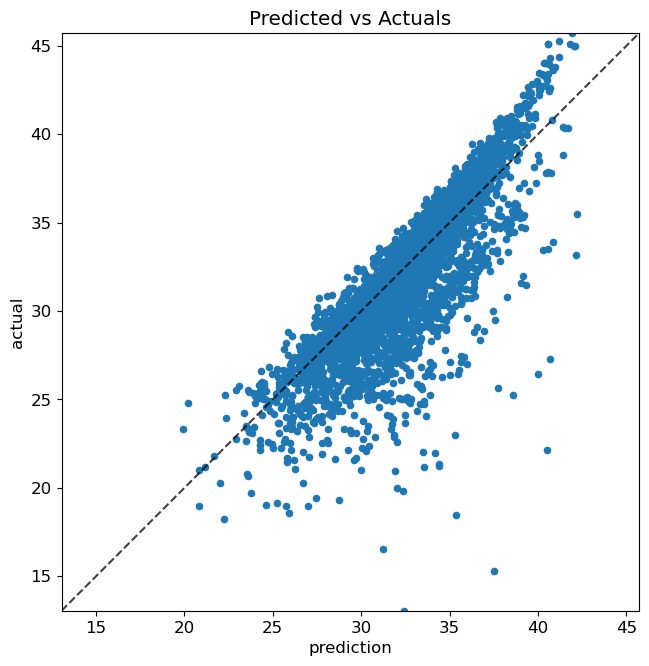

In [19]:
# using p = 0.5, which is also the default
GAT_model3 = GATConvModel3(qm9.num_features, h = 64)

epochs = 200
loss_function = torch.nn.MSELoss()
optimizer = torch.optim.Adam(GAT_model3.parameters(), lr = 0.001)

GAT_model3, tlosses3, vlosses3 = train_model(GAT_model3, epochs, loss_function, optimizer, train_loader, val_loader)

test_out3, test_y3 = evaluate_test(GAT_model3, test_loader)

# denormalize
denorm_out3 = (test_out3 * train_std) + train_mean
denorm_y3 = (test_y3 * train_std) + train_mean
print(f"Test loss:{loss_function(denorm_out3, denorm_y3).item():.6e}")

preds3 = denorm_out3.cpu().detach().numpy()
actual3 = denorm_y3.cpu().detach().numpy()

plot_pred_v_actual(preds3, actual3)

Epoch 0: training loss:2.971856e-07, validation loss:3.059112e-07
Epoch 50: training loss:2.900233e-07, validation loss:3.253249e-07
Epoch 99: training loss:2.919462e-07, validation loss:2.924401e-07
2.497865e-07
5.326845e+00


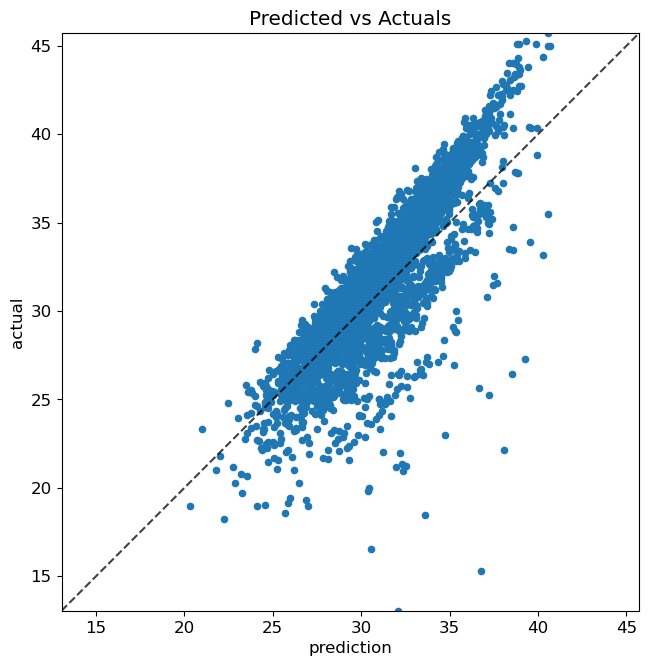

In [20]:
# let's continue training to see if it improves or worsens predictions
# how much more we should train
epochs = 100

GAT_model3, tlosses3, vlosses3 = train_model(GAT_model3, epochs, loss_function, optimizer, train_loader, val_loader)

test_out3, test_y3 = evaluate_test(GAT_model3, test_loader)

# denormalize
denorm_out3 = (test_out3 * train_std) + train_mean
denorm_y3 = (test_y3 * train_std) + train_mean
print(f"Test loss:{loss_function(denorm_out3, denorm_y3).item():.6e}")

preds3 = denorm_out3.cpu().detach().numpy()
actual3 = denorm_y3.cpu().detach().numpy()

plot_pred_v_actual(preds3, actual3)

## More Pytorch Geometric Models to Explore
There are MANY more convolutional layers and completed models readily available in PyG. Check them out here and try creating your own combination of layers. 

&rarr; https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html

Also try different pooling options and compare the effects. 

This tutorial just introduces the QM9 dataset usage, but there are **MANY** other collabs you can check out: 

&rarr; https://pytorch-geometric.readthedocs.io/en/latest/get_started/colabs.html

## MPNNs

MPNN = Message Passing Neural Network

MPNNs are frameworks for graph nns where the focus is on the message passing, aggregation and updating. 

Like GATs, they are considered spatial GNNs, convolution is defined by aggregating neighbors. 


In [34]:
# MPNN 
import torch.nn as nn
from torch.nn import Sequential
from torch_geometric.nn import MessagePassing

# create the message passing layer to use in our model
class MPNNLayer(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='add')  
        self.message_mlp = Sequential(
            Linear(2 * in_channels, out_channels),
            ReLU(),
            Linear(out_channels, out_channels)
        )
        self.update_mlp = Sequential(
            Linear(in_channels + out_channels, out_channels),
            ReLU()
        )

    def forward(self, x, edge_index):
        return self.propagate(edge_index, x=x)

    # notice the x_i, x_j here
    # this is telling PyG's MessagePassing class to:
    # compute x_j : features of source nodes
    # compute x_i : features of target nodes
    # the _i or _j suffix is used to automatically extract and align the node features during message passing
    def message(self, x_i, x_j):
        # Concatenate features of sender and receiver
        m = torch.cat([x_i, x_j], dim=1)
        return self.message_mlp(m)

    def update(self, aggr_out, x):
        return self.update_mlp(torch.cat([x, aggr_out], dim=1))


class MPNN(torch.nn.Module):
    def __init__(self, num_feats, h):
        super().__init__()
        self.lin0 = Linear(num_feats, h)
        self.lin1 = Linear(h, 1)
        
        self.mpl0 = MPNNLayer(h, h)
        self.mpl1 = MPNNLayer(h, h)
        self.mpl2 = MPNNLayer(h, h)
        
        

    def forward(self, data):
        e = data.edge_index
        x = data.x
        # starting with a linear layer - this lets us project node features to the latent space
        # where there are more dimensions (since h is often 64 or 128)
        x = self.lin0(x)
        # three message passing layers
        x = self.mpl0(x, e)
        x = self.mpl1(x, e)
        x = self.mpl2(x, e)
        # pooling layer
        x = global_mean_pool(x, data.batch)  
        # return a single value prediction
        return self.lin1(x)



Epoch 0: training loss:3.422480e-03, validation loss:2.678276e-05
Epoch 50: training loss:6.658951e-07, validation loss:6.749853e-07
Epoch 100: training loss:1.141913e-06, validation loss:3.184451e-07
Epoch 150: training loss:9.416615e-07, validation loss:6.353235e-07
Epoch 199: training loss:5.905469e-07, validation loss:4.135568e-07
3.829098e-07
8.165777e+00


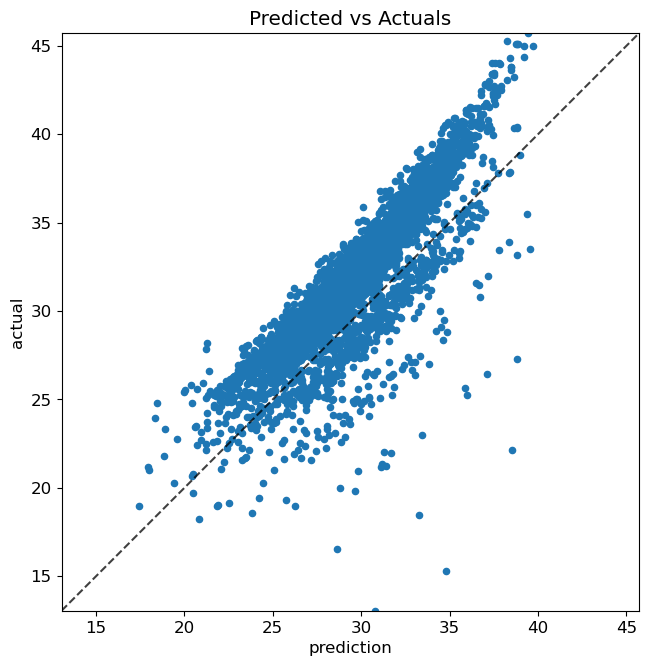

In [36]:
MPNN_model = MPNN(qm9.num_features, h = 64)
epochs = 200
loss_function = torch.nn.MSELoss()

optimizer = torch.optim.Adam(MPNN_model.parameters(), lr = 0.001)

MPNN_model, MPNN_tlosses, MPNN_vlosses = train_model(MPNN_model, epochs, loss_function, optimizer, train_loader, val_loader)

MPNN_test_out, MPNN_test_y = evaluate_test(MPNN_model, test_loader)

# denormalize
MPNN_denorm_out = (MPNN_test_out * train_std) + train_mean
MPNN_denorm_y = (MPNN_test_y * train_std) + train_mean
print(f"Test loss:{loss_function(MPNN_denorm_out, MPNN_denorm_y).item():.6e}")

MPNN_preds = MPNN_denorm_out.cpu().detach().numpy()
MPNN_actual = MPNN_denorm_y.cpu().detach().numpy()

plot_pred_v_actual(MPNN_preds, MPNN_actual)


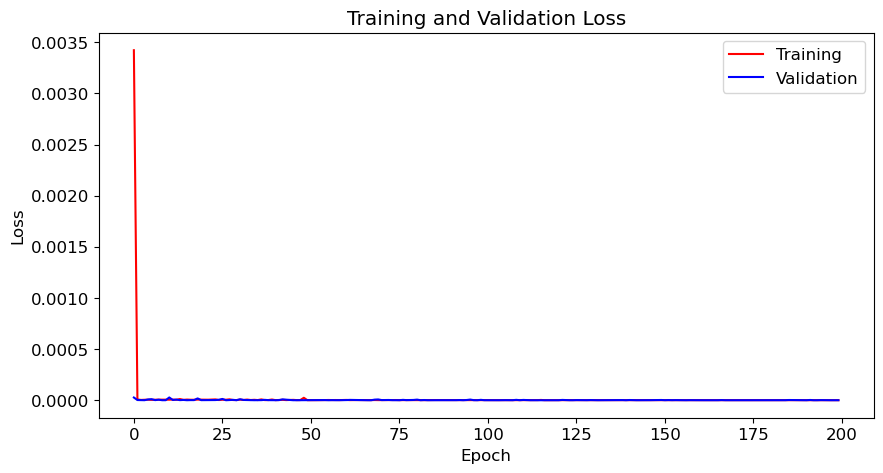

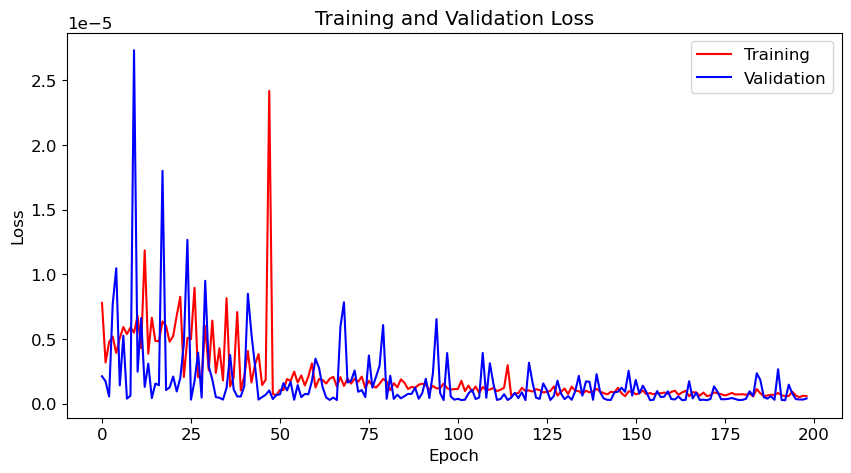

In [38]:
# Look at the losses
plot_losses(MPNN_tlosses, MPNN_vlosses)

# Let's omit the first loss and see if that helps with the visualization
plot_losses(MPNN_tlosses[1:], MPNN_vlosses[1:])


Epoch 0: training loss:8.131410e-07, validation loss:1.053274e-06
Epoch 50: training loss:4.931479e-07, validation loss:2.806306e-07
Epoch 100: training loss:4.395567e-07, validation loss:2.927830e-07
Epoch 150: training loss:4.143583e-07, validation loss:4.861906e-07
Epoch 199: training loss:3.690525e-07, validation loss:3.458516e-07
2.994825e-07
6.386640e+00


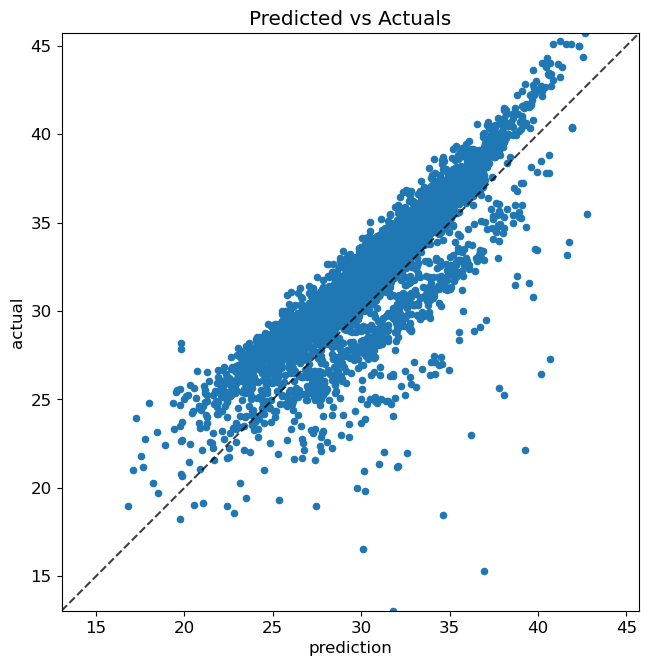

In [39]:
# Try training it a bit longer
epochs = 200
MPNN_model, MPNN_tlosses2, MPNN_vlosses2 = train_model(MPNN_model, epochs, loss_function, optimizer, train_loader, val_loader)
MPNN_tlosses.extend(MPNN_tlosses2)
MPNN_vlosses.extend(MPNN_vlosses2)

MPNN_test_out, MPNN_test_y = evaluate_test(MPNN_model, test_loader)

# denormalize
MPNN_denorm_out = (MPNN_test_out * train_std) + train_mean
MPNN_denorm_y = (MPNN_test_y * train_std) + train_mean
print(f"Test loss:{loss_function(MPNN_denorm_out, MPNN_denorm_y).item():.6e}")

MPNN_preds = MPNN_denorm_out.cpu().detach().numpy()
MPNN_actual = MPNN_denorm_y.cpu().detach().numpy()

plot_pred_v_actual(MPNN_preds, MPNN_actual)



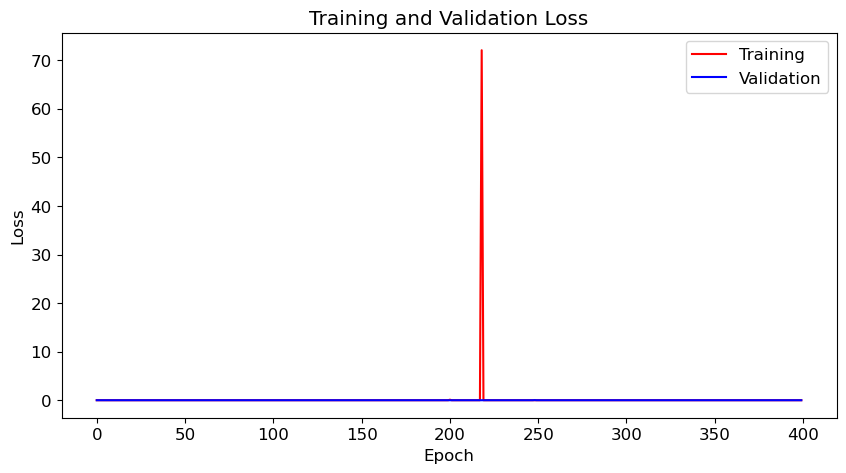

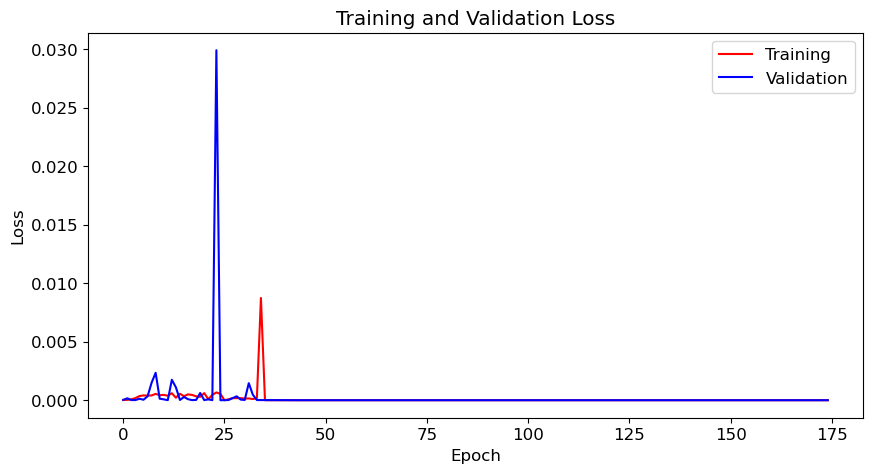

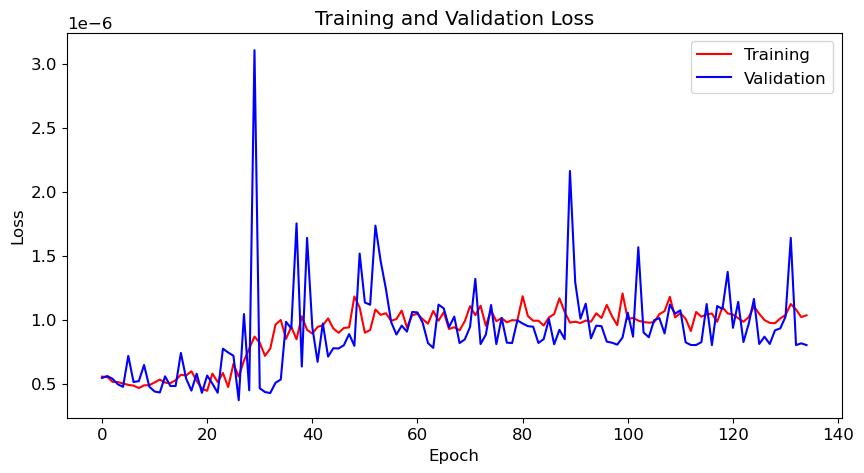

In [ ]:
# Look at the losses
plot_losses(MPNN_tlosses, MPNN_vlosses)
# let's start the plot farther along, keep in mind this is going to have mislabeled x-axis since the count isn't starting at 0
# but it will be labeled that way on the plot
plot_losses(MPNN_tlosses[225:], MPNN_vlosses[225:])
plot_losses(MPNN_tlosses[265:], MPNN_vlosses[265:])

Epoch 0: training loss:3.019034e-07, validation loss:3.458501e-07
Epoch 50: training loss:3.019037e-07, validation loss:3.458513e-07
Epoch 100: training loss:3.019042e-07, validation loss:3.458511e-07
Epoch 150: training loss:3.019037e-07, validation loss:3.458512e-07
Epoch 199: training loss:3.019041e-07, validation loss:3.458516e-07
2.994832e-07
Test loss:6.386657e+00


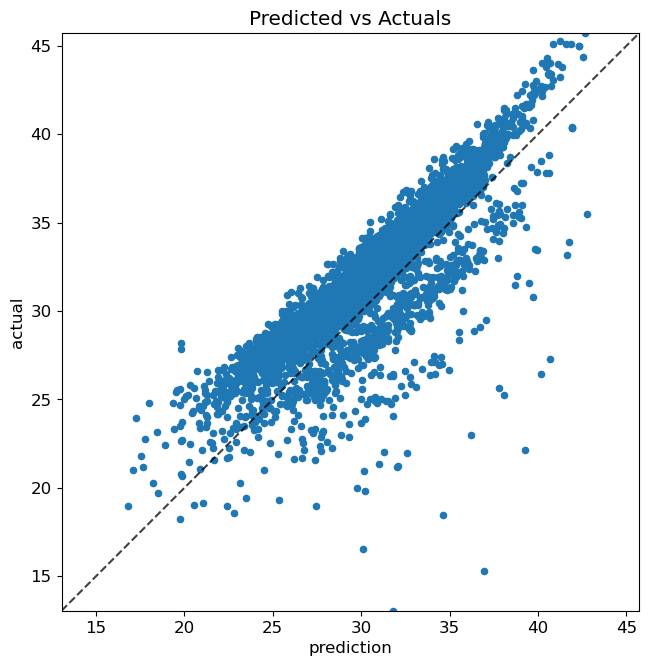

In [45]:
# Try training longer?
epochs = 200
MPNN_model, MPNN_tlosses3, MPNN_vlosses3 = train_model(MPNN_model, epochs, loss_function, optimizer, train_loader, val_loader)
MPNN_tlosses.extend(MPNN_tlosses3)
MPNN_vlosses.extend(MPNN_vlosses3)
MPNN_test_out, MPNN_test_y = evaluate_test(MPNN_model, test_loader)

# denormalize
MPNN_denorm_out = (MPNN_test_out * train_std) + train_mean
MPNN_denorm_y = (MPNN_test_y * train_std) + train_mean
print(f"Test loss:{loss_function(MPNN_denorm_out, MPNN_denorm_y).item():.6e}")

MPNN_preds = MPNN_denorm_out.cpu().detach().numpy()
MPNN_actual = MPNN_denorm_y.cpu().detach().numpy()

plot_pred_v_actual(MPNN_preds, MPNN_actual)

At this point, we see the training and validation losses are no longer changing, so let's look at other options.

Epoch 0: training loss:2.767082e-03, validation loss:2.472139e-05
Epoch 50: training loss:2.532714e-06, validation loss:2.426500e-06
Epoch 100: training loss:1.001074e-06, validation loss:2.396363e-06
Epoch 150: training loss:4.773339e-07, validation loss:7.308632e-07
Epoch 199: training loss:5.897762e-07, validation loss:3.324578e-07
2.990955e-07
6.378389e+00


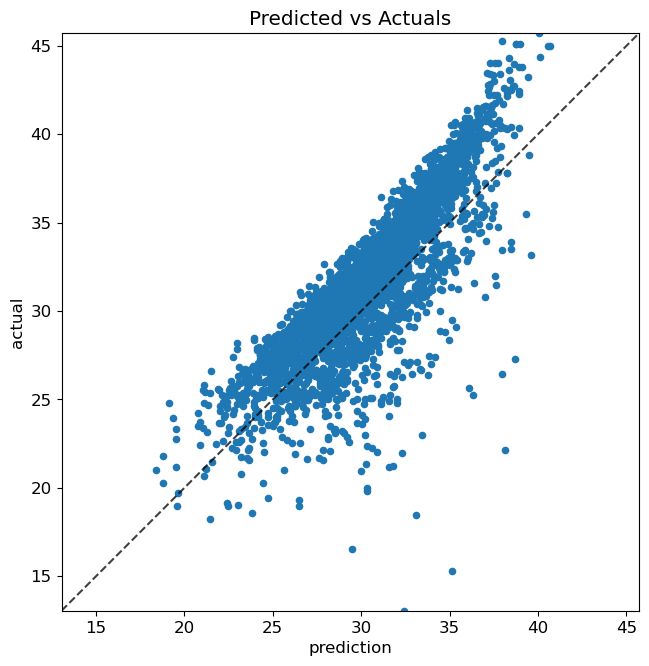

In [55]:
# let's try an adjustment and increase the number of hidden layers

MPNN_model2 = MPNN(qm9.num_features, h = 128)
epochs = 200
loss_function = torch.nn.MSELoss()

optimizer = torch.optim.Adam(MPNN_model2.parameters(), lr = 0.001)

MPNN_model2, MPNN_tlosses2, MPNN_vlosses2 = train_model(MPNN_model2, epochs, loss_function, optimizer, train_loader, val_loader)

MPNN_test_out2, MPNN_test_y2 = evaluate_test(MPNN_model2, test_loader)

# denormalize
MPNN_denorm_out2 = (MPNN_test_out2 * train_std) + train_mean
MPNN_denorm_y2 = (MPNN_test_y2 * train_std) + train_mean
print(f"Test loss:{loss_function(MPNN_denorm_out2, MPNN_denorm_y2).item():.6e}")

MPNN_preds2 = MPNN_denorm_out2.cpu().detach().numpy()
MPNN_actual2 = MPNN_denorm_y2.cpu().detach().numpy()

plot_pred_v_actual(MPNN_preds2, MPNN_actual2)


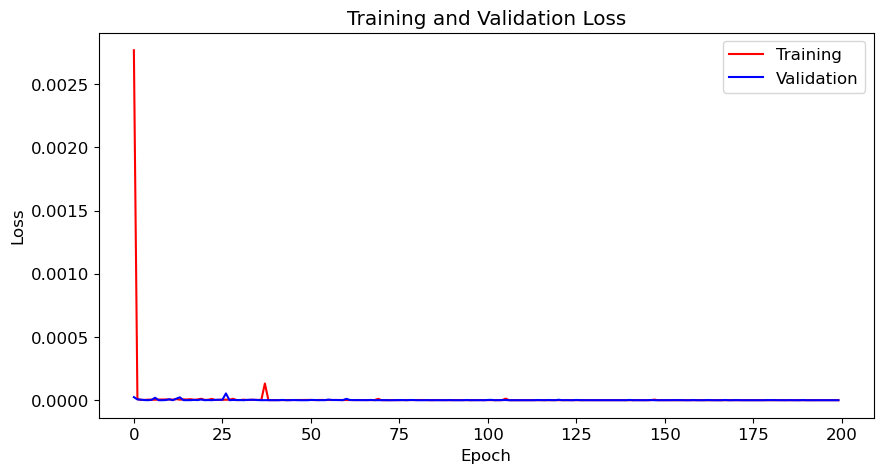

In [56]:
plot_losses(MPNN_tlosses2, MPNN_vlosses2)

There are plenty of different parameters to set and modifications you can make to the layers. Don't be afraid to try different things to see what happens.